In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from python_scripts.preprocessing import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [2]:
sgr_df = pickle.load(open('../CIFAR2/sgr_set_cnn','rb')) 
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-2 dataset

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.929581
2944,0.0,0.0,0.982615
2024,1.0,1.0,0.542768
263,0.0,0.0,0.822609
4350,0.0,0.0,0.953512


In [3]:
delta = 0.001

### <font color = 'yellow'> Evolution of bounds with $\theta$

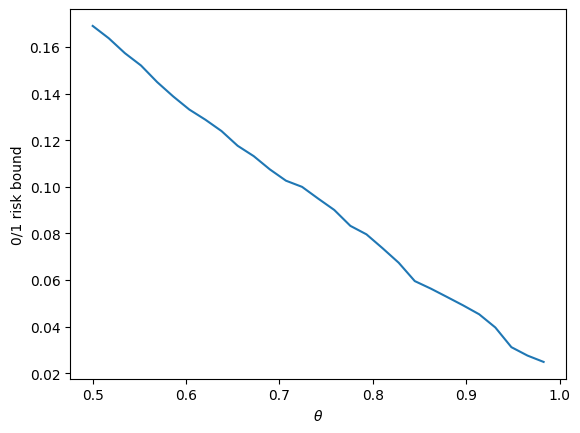

In [4]:
thetas, bounds = bound_evo_w_theta('standard', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('0/1 risk bound')
plt.show()

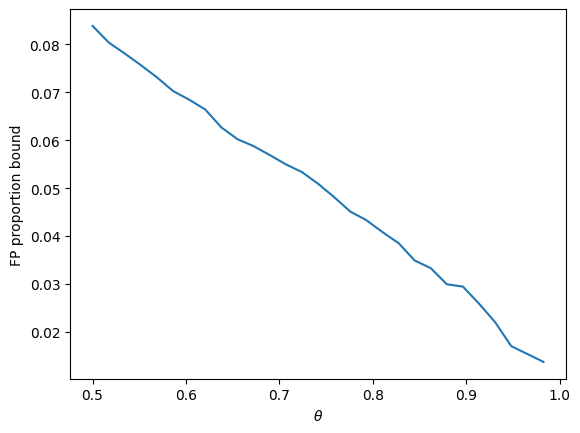

In [5]:
thetas, bounds = bound_evo_w_theta('FP', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FP proportion bound')
plt.show()

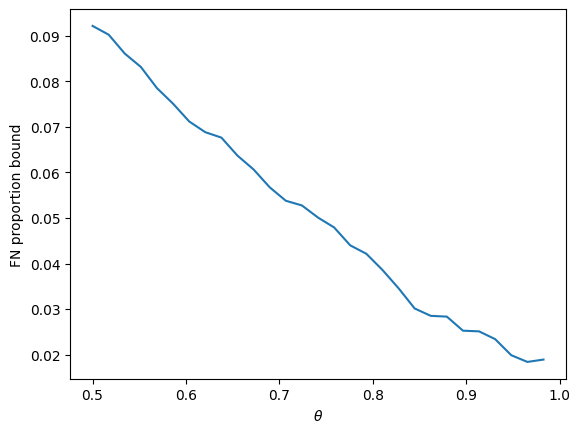

In [6]:
thetas, bounds = bound_evo_w_theta('FN', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FN proportion bound')
plt.show()

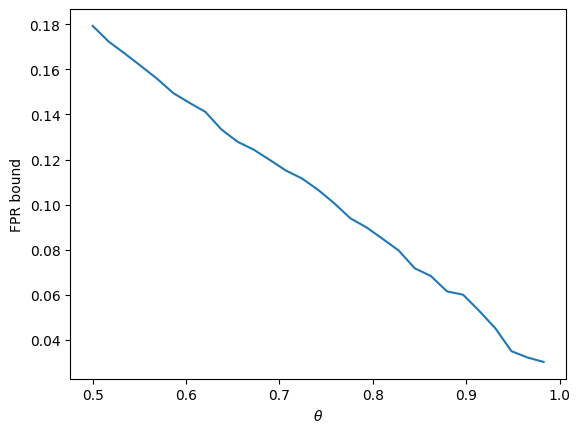

In [7]:
thetas, bounds = bound_evo_w_theta('FPR', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FPR bound')
plt.show()

C:\Users\Emilien JEMELEN\AppData\Local\Temp\ipykernel_16024\1614333483.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


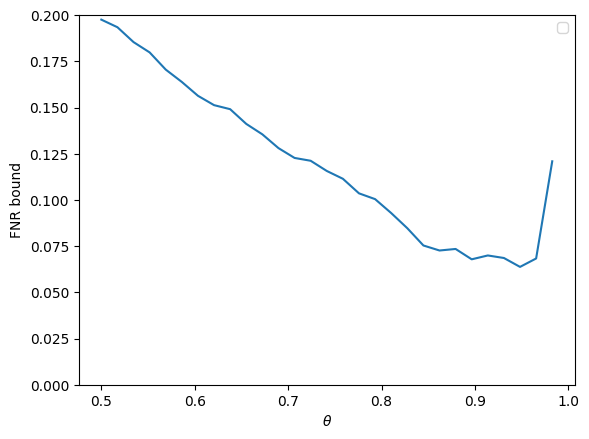

In [8]:
thetas, bounds = bound_evo_w_theta('FNR', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FNR bound')
plt.legend()
plt.ylim(0,0.2)
plt.show()

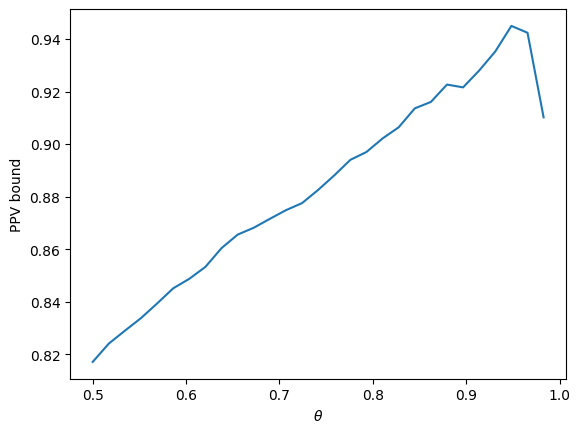

In [9]:
thetas, bounds = bound_evo_w_theta('PPV', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('PPV bound')
plt.show()

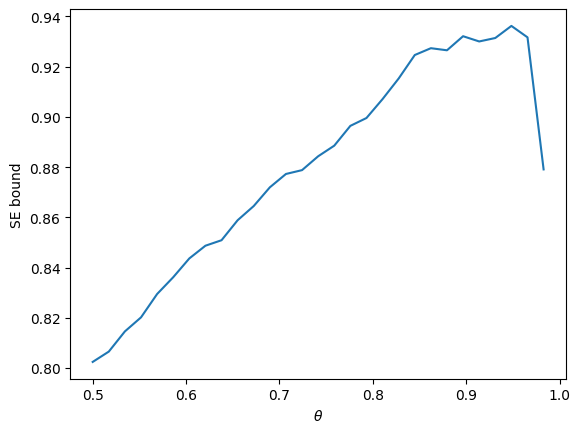

In [10]:
thetas, bounds = bound_evo_w_theta('SE', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('SE bound')
plt.show()

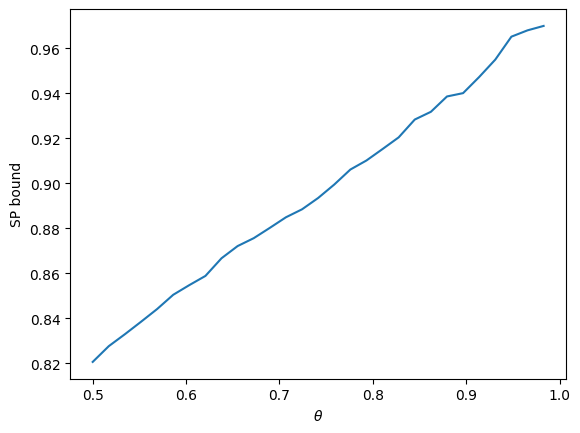

In [11]:
thetas, bounds = bound_evo_w_theta('SP', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('SP bound')
plt.show()

### <font color='yellow'> Evolution of proportion of 1s in selected samples with $\theta$

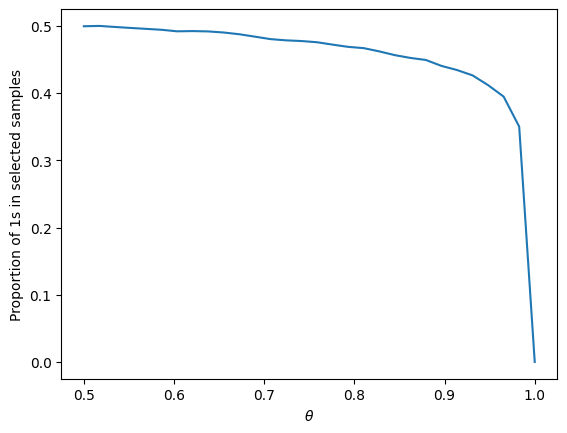

In [12]:
thetas, pos_propors = pos_propor_w_theta(sgr_df, steps=30)
plt.plot(thetas, pos_propors)
plt.xlabel(r'$\theta$')
plt.ylabel('Proportion of 1s in selected samples')
plt.show()

__Comment__: 1s proportion concave drop when demanded classifier confidence gets close to 1 means that classifier tends to be highly confident in its class-0/airplane predictions more than in its class-1/car predictions. 

In other words, facing equal numbers of airplane pictures and car pictures, the classifier will say "I'm sure this picture is an airplane" a lot more often than "I'm sure this picture is a car"  

### <font color = 'yellow'> Joint control over a set of metrics

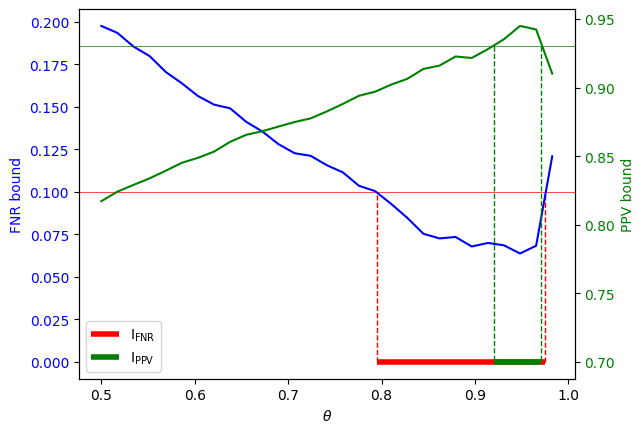

In [13]:
fig, ax1 = plt.subplots()

# First y-axis (FNR)
thetas, bounds = bound_evo_w_theta('FNR', sgr_df, delta, steps=30)
ax1.axhline(0.1, color='r', linewidth=0.5)
ax1.vlines(0.795, 0, 0.1, colors='r', linewidth=1, linestyle='--')
ax1.vlines(0.975, 0, 0.1, colors='r', linewidth=1, linestyle='--')
theta_region_fnr = ax1.hlines(0, 0.795, 0.975, colors='r', linewidth=4, label=r'$\text{I}_{\text{FNR}}$')
ax1.plot(thetas, bounds, color='blue')
ax1.set_xlabel(r'$\theta$')
ax1.set_ylabel('FNR bound', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Second y-axis (PPV)
ax2 = ax1.twinx()
thetas, bounds = bound_evo_w_theta('PPV', sgr_df, delta, steps=30)
ax2.axhline(0.93, color='green', linewidth=0.5)
ax2.vlines(0.92, 0.93, 0.7, colors='green', linewidth=1, linestyle='--')
ax2.vlines(0.971, 0.93, 0.7, colors='green', linewidth=1, linestyle='--')
theta_region_ppv = ax2.hlines(0.7, 0.92, 0.971, colors='green', linewidth=4, label=r'$\text{I}_{\text{PPV}}$')
ax2.plot(thetas, bounds, color='green')
ax2.set_ylabel('PPV bound', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Show legend
ax1.legend(handles=[theta_region_fnr,theta_region_ppv], loc='lower left')
plt.show()
